In [ ]:
import requests
import pandas as pd

url = "https://en.wikipedia.org/wiki/List_of_countries_and_dependencies_by_population"

headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)
html = response.text

Extract Table Using Pandas

In [ ]:
tables = pd.read_html(html)

print(len(tables))   # check how many tables

3


/tmp/ipykernel_2919/1212722658.py:1: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


Select Correct Table

In [ ]:
df = tables[0]   # usually first table

print(df.head())
print(df.columns)

        Location  Population % of world         Date  \
0          World  8232000000       100%  13 Jun 2025   
1          India  1417492000      17.2%   1 Jul 2025   
2          China  1404890000      17.0%  31 Dec 2025   
3  United States   341784857       4.1%   1 Jul 2025   
4      Indonesia   288315089       3.5%  31 Dec 2025   

  Source (official or from the United Nations) Notes  
0                          UN projection[1][3]   NaN  
1                       Official projection[4]   [b]  
2                         Official estimate[5]   [c]  
3                         Official estimate[6]   [d]  
4                National annual projection[7]   NaN  
Index(['Location', 'Population', '% of world', 'Date',
       'Source (official or from the United Nations)', 'Notes'],
      dtype='object')


Show Column

In [ ]:
print(df.columns)

Index(['Location', 'Population', '% of world', 'Date',
       'Source (official or from the United Nations)', 'Notes'],
      dtype='object')


Rename Column

In [ ]:
df.rename(columns={
    "Location": "Country",
    "Population": "Population",
    "% of world": "Percent"
}, inplace=True)

Select Column

In [ ]:
df = df[["Country", "Population", "Percent", "Date"]]

Clean Data

In [ ]:
df["Population"] = df["Population"].astype(str)

df["Population"] = df["Population"].str.replace(",", "")
df["Population"] = df["Population"].str.replace(r"\[.*?\]", "", regex=True)

df["Population"] = pd.to_numeric(df["Population"], errors="coerce")

df.dropna(inplace=True)

print(df.shape)
print(df.head())

(33, 4)
         Country  Population Percent         Date
1          India  1417492000   17.2%   1 Jul 2025
2          China  1404890000   17.0%  31 Dec 2025
3  United States   341784857    4.1%   1 Jul 2025
5       Pakistan   241499431    2.9%   1 Mar 2023
8     Bangladesh   169828911    2.1%  14 Jun 2022


/tmp/ipykernel_2919/1119950733.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Population"] = df["Population"].astype(str)
/tmp/ipykernel_2919/1119950733.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Population"] = df["Population"].str.replace(",", "")
/tmp/ipykernel_2919/1119950733.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.py

#EDA

Final Clean Check

In [ ]:
print(df.shape)
print(df.info())
print(df.describe())

(33, 4)
<class 'pandas.core.frame.DataFrame'>
Index: 33 entries, 1 to 237
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Country     33 non-null     object
 1   Population  33 non-null     int64 
 2   Percent     33 non-null     object
 3   Date        33 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.3+ KB
None
         Population
count  3.300000e+01
mean   1.283187e+08
std    3.394982e+08
min    8.820000e+02
25%    3.704500e+06
50%    1.813726e+07
75%    6.815300e+07
max    1.417492e+09


Top 10 Countries

In [ ]:
top10 = df.sort_values(by="Population", ascending=False).head(10)
print(top10)

           Country  Population Percent         Date
1            India  1417492000   17.2%   1 Jul 2025
2            China  1404890000   17.0%  31 Dec 2025
3    United States   341784857    4.1%   1 Jul 2025
5         Pakistan   241499431    2.9%   1 Mar 2023
8       Bangladesh   169828911    2.1%  14 Jun 2022
9           Russia   146028325    1.8%   1 Jan 2025
20  United Kingdom    69487000    0.8%  30 Jun 2025
21          France    69081996    0.8%   1 Jan 2026
22        Tanzania    68153004    0.8%   1 Jul 2025
29         Myanmar    51375327    0.6%  15 Oct 2024


Visualization

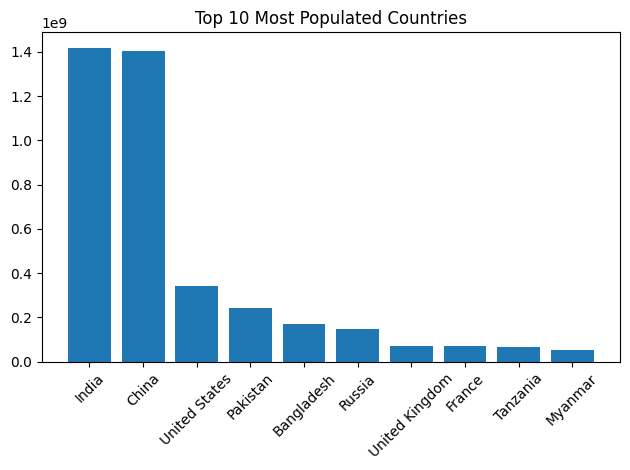

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(top10["Country"], top10["Population"])
plt.xticks(rotation=45)
plt.title("Top 10 Most Populated Countries")
plt.tight_layout()
plt.show()

Population Distribution

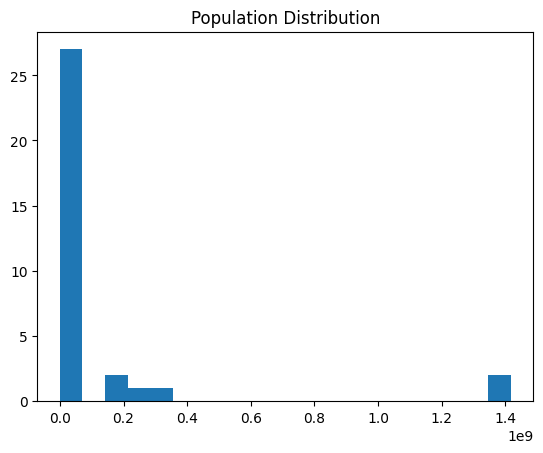

In [ ]:
plt.figure()
plt.hist(df["Population"], bins=20)
plt.title("Population Distribution")
plt.show()

Outlier Detection

In [ ]:
lowest = df.sort_values(by="Population").head(10)
print(lowest)

             Country  Population  Percent         Date
237     Vatican City         882       0%  31 Dec 2024
208    South Ossetia       56520  0.0007%  31 Dec 2021
185         Abkhazia      244236   0.003%   1 Jan 2022
180     Transnistria      367776   0.004%  31 Mar 2024
175  Northern Cyprus      476214   0.006%  31 Dec 2023
161           Cyprus      983000    0.01%  31 Dec 2024
144          Moldova     2381300    0.03%   1 Jan 2025
132          Eritrea     3607000    0.04%   1 Jul 2025
131          Georgia     3704500    0.04%   1 Jan 2025
124      New Zealand     5342000    0.06%  31 Dec 2025


Summary Statistics

In [ ]:
print(df["Population"].describe())

count    3.300000e+01
mean     1.283187e+08
std      3.394982e+08
min      8.820000e+02
25%      3.704500e+06
50%      1.813726e+07
75%      6.815300e+07
max      1.417492e+09
Name: Population, dtype: float64
